In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

training_dataset = pd.read_csv('../data/raw/train.csv')
testing_dataset = pd.read_csv('../data/raw/test.csv')

train_dimensions = training_dataset.shape
test_dimensions = testing_dataset.shape

print("Train shape:", train_dimensions)
print("Test shape:", test_dimensions)

print("\nFirst 5 rows:")
first_five_rows = training_dataset.head()
print(first_five_rows)

Train shape: (690088, 15)
Test shape: (295753, 14)

First 5 rows:
   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   
3   3        unhealthy            4.70        77.2  23.13   
4   4          at-risk            7.23        73.4  28.44   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0               2174.0      1326.0               19.8          1.86       veg   
1               1966.0      9891.0               49.9          1.26   non-veg   
2               2688.0     14216.0               38.1          1.60       veg   
3               2630.0      7174.0               59.9          2.02       veg   
4               2560.0      6584.0               46.0          2.25       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  
0

In [2]:
print("Dataset Info:")
training_dataset.info()

print("\nMissing values in train:")
missing_train = training_dataset.isnull().sum()
missing_train_pct = (missing_train / len(training_dataset)) * 100
missing_summary = pd.DataFrame({'missing_count': missing_train, 'missing_pct': missing_train_pct})
print(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False))

print("\nMissing values in test:")
missing_test = testing_dataset.isnull().sum()
missing_test_pct = (missing_test / len(testing_dataset)) * 100
missing_summary_test = pd.DataFrame({'missing_count': missing_test, 'missing_pct': missing_test_pct})
print(missing_summary_test[missing_summary_test['missing_count'] > 0].sort_values('missing_pct', ascending=False))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  g

Target distribution (counts):
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Target distribution (%):
health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64


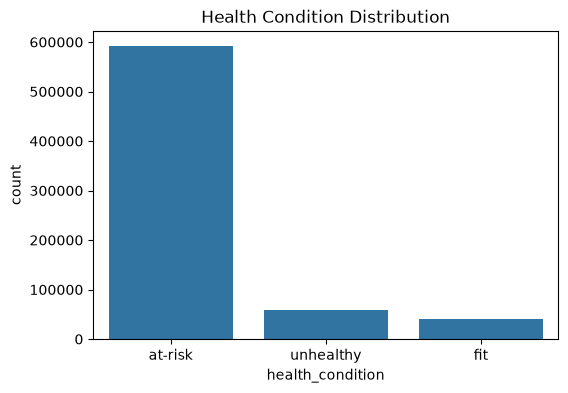

In [3]:
print("Target distribution (counts):")
print(training_dataset['health_condition'].value_counts())

print("\nTarget distribution (%):")
print(training_dataset['health_condition'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=training_dataset, x='health_condition', order=training_dataset['health_condition'].value_counts().index)
plt.title('Health Condition Distribution')
plt.show()

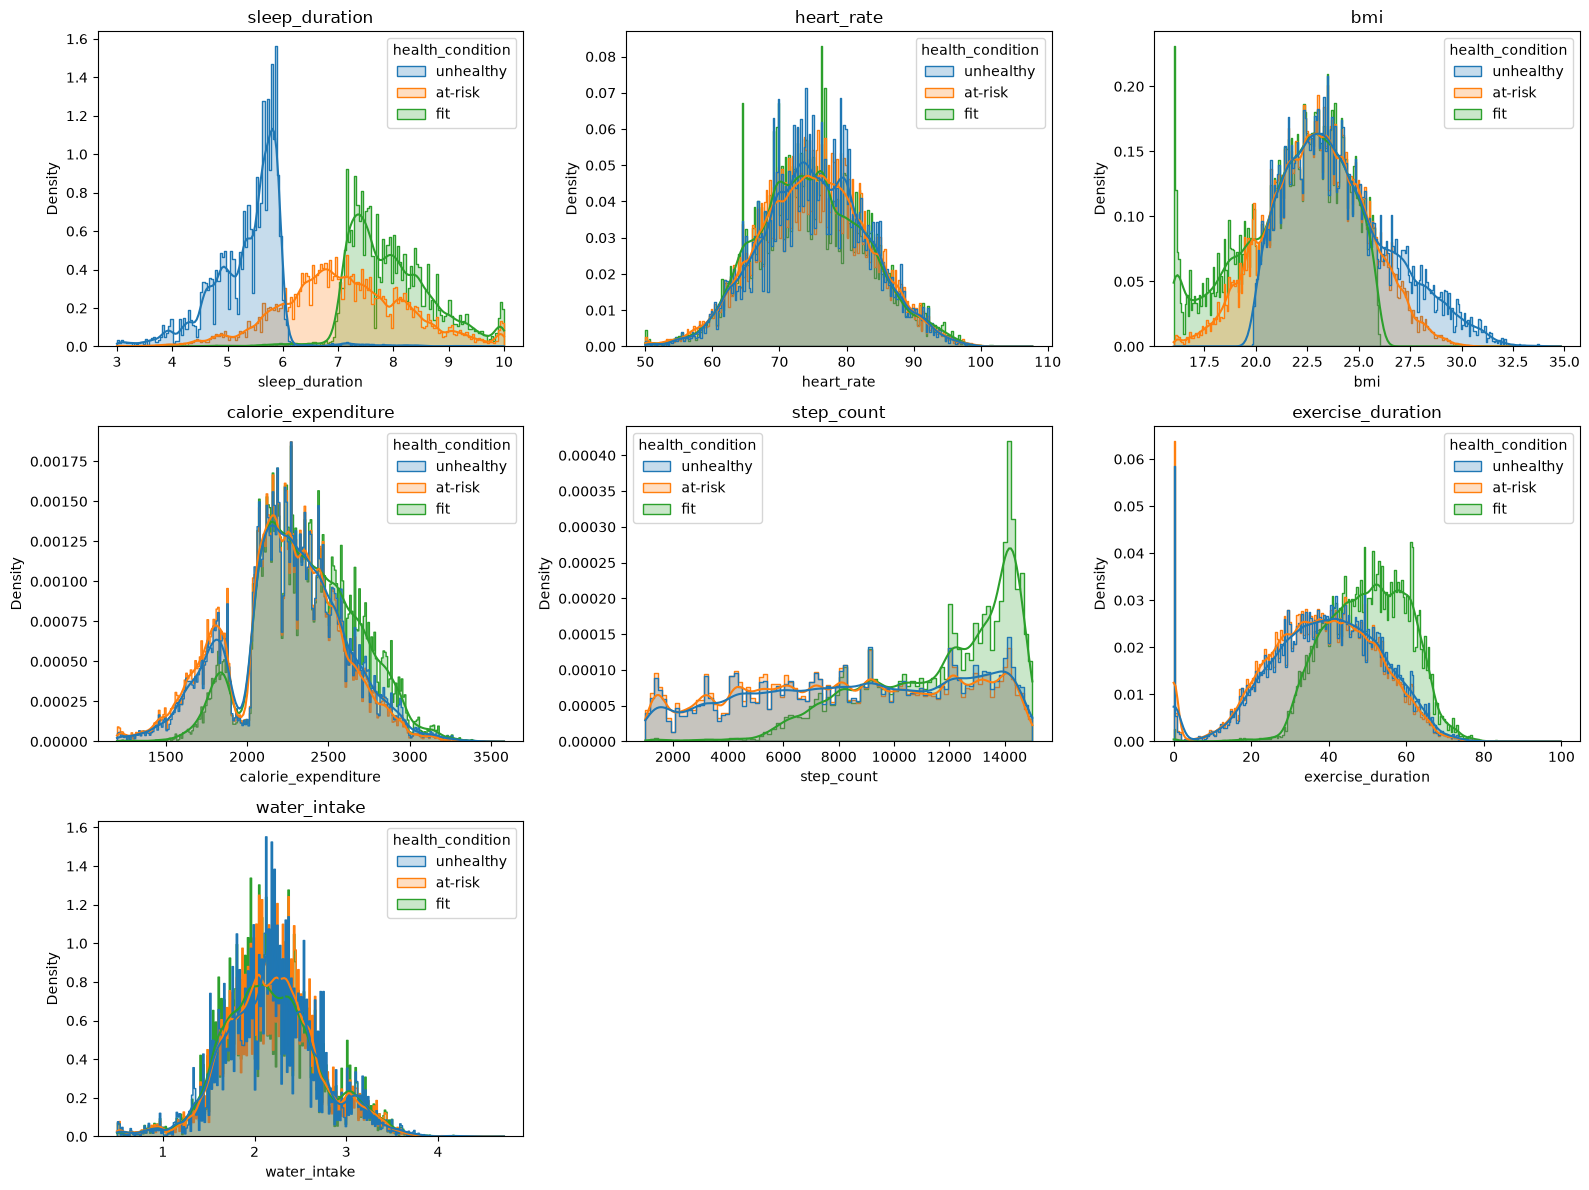

In [4]:
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 
                 'step_count', 'exercise_duration', 'water_intake']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=training_dataset, x=col, hue='health_condition', 
                 kde=True, ax=axes[i], element='step', stat='density', common_norm=False)
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Crosstab: diet_type vs health_condition (row %)
health_condition  at-risk   fit  unhealthy
diet_type                                 
balanced            85.14  6.12       8.74
non-veg             86.78  5.16       8.06
veg                 85.67  6.04       8.30

Crosstab: stress_level vs health_condition (row %)
health_condition  at-risk    fit  unhealthy
stress_level                               
high                71.78   0.35      27.87
low                 79.67  20.06       0.28
medium              99.39   0.30       0.31

Crosstab: sleep_quality vs health_condition (row %)
health_condition  at-risk   fit  unhealthy
sleep_quality                             
average             85.93  5.73       8.34
good                88.78  8.17       3.05
poor                82.96  3.46      13.58

Crosstab: physical_activity_level vs health_condition (row %)
health_condition         at-risk    fit  unhealthy
physical_activity_level                           
active                     74.3

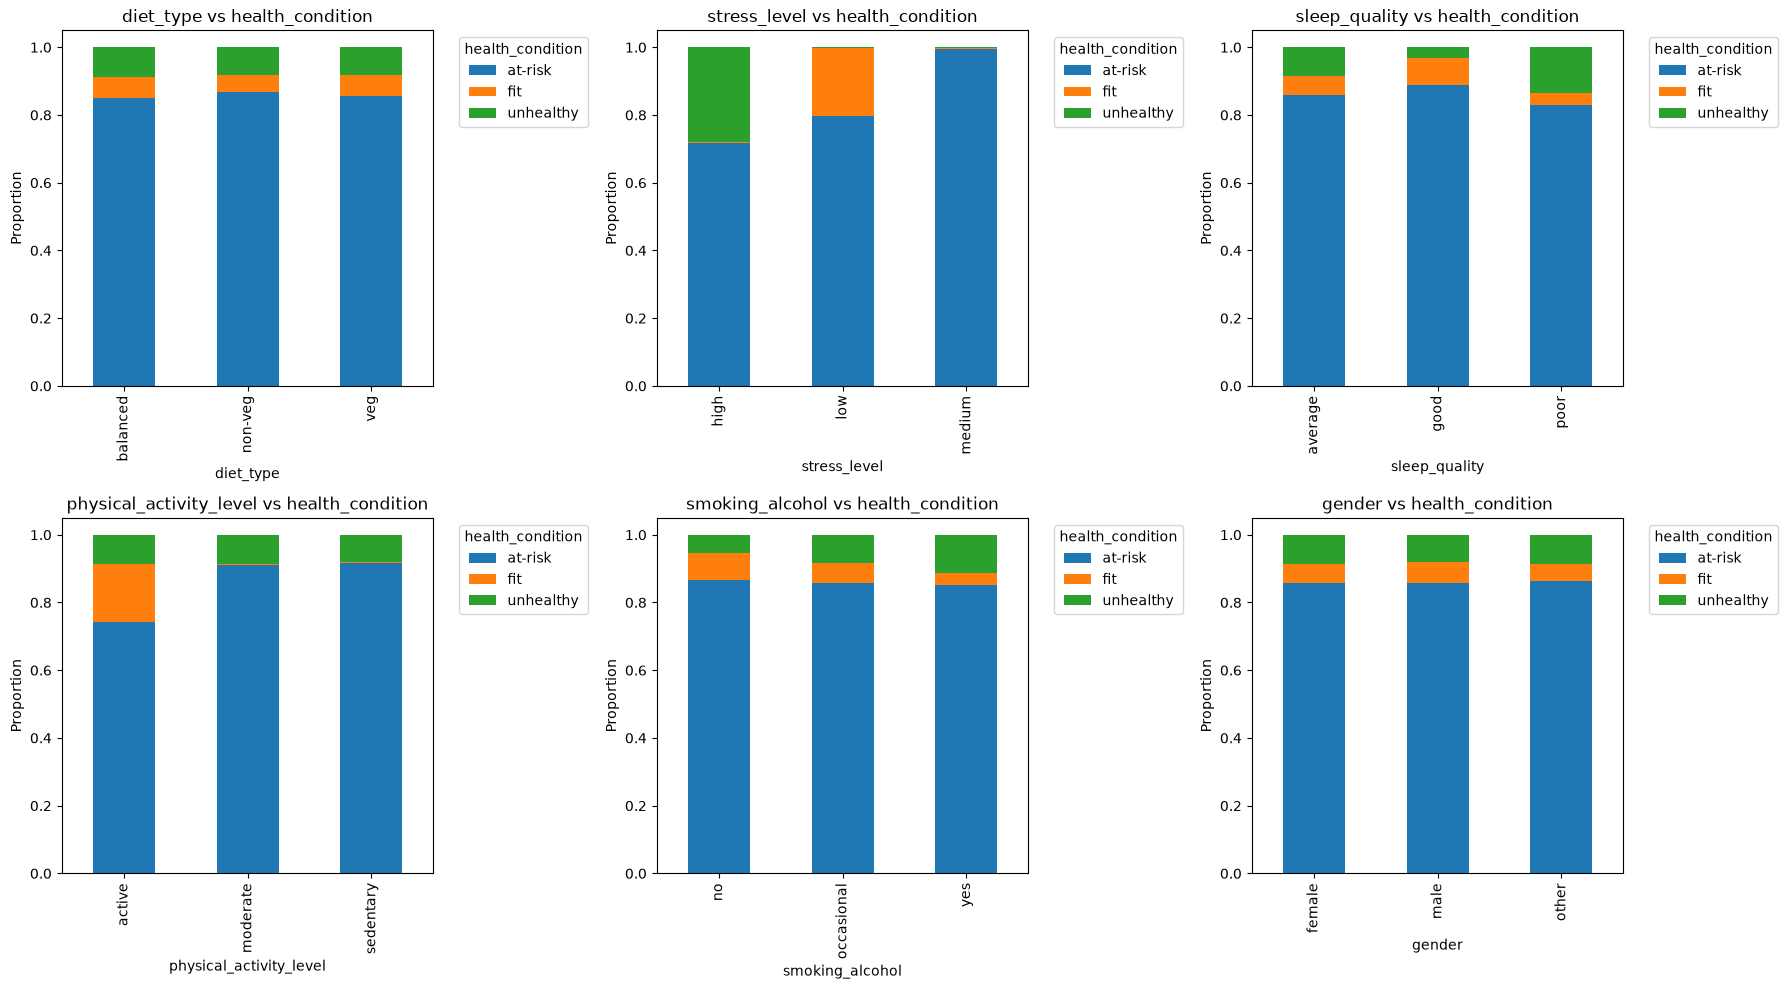

In [5]:
categorical_cols = ['diet_type', 'stress_level', 'sleep_quality', 
                     'physical_activity_level', 'smoking_alcohol', 'gender']

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Crosstab: {col} vs health_condition (row %)")
    print('='*60)
    crosstab = pd.crosstab(training_dataset[col], training_dataset['health_condition'], normalize='index') * 100
    print(crosstab.round(2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    crosstab_plot = pd.crosstab(training_dataset[col], training_dataset['health_condition'], normalize='index')
    crosstab_plot.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs health_condition')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='health_condition', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [ ]:
for col in ['stress_level', 'physical_activity_level', 'sleep_duration']:
    training_dataset[f'{col}_missing'] = training_dataset[col].isnull()
    print(f"\n{col} missing vs health_condition:")
    print(pd.crosstab(training_dataset[f'{col}_missing'], training_dataset['health_condition'], normalize='index').round(4) * 100)


stress_level missing vs health_condition:
health_condition      at-risk   fit  unhealthy
stress_level_missing                          
False                   85.86  5.77       8.37
True                    85.89  5.75       8.36

physical_activity_level missing vs health_condition:
health_condition                 at-risk   fit  unhealthy
physical_activity_level_missing                          
False                              85.86  5.77       8.37
True                               85.94  5.72       8.34

sleep_duration missing vs health_condition:
health_condition        at-risk   fit  unhealthy
sleep_duration_missing                          
False                     85.86  5.77       8.37
True                      85.93  5.73       8.34


Correlation matrix:
                     sleep_duration  heart_rate    bmi  calorie_expenditure  \
sleep_duration                1.000      -0.005 -0.075               -0.004   
heart_rate                   -0.005       1.000  0.001               -0.004   
bmi                          -0.075       0.001  1.000                0.118   
calorie_expenditure          -0.004      -0.004  0.118                1.000   
step_count                    0.004      -0.005 -0.021                0.400   
exercise_duration             0.002      -0.006 -0.020                0.394   
water_intake                  0.001       0.000  0.001                0.002   

                     step_count  exercise_duration  water_intake  
sleep_duration            0.004              0.002         0.001  
heart_rate               -0.005             -0.006         0.000  
bmi                      -0.021             -0.020         0.001  
calorie_expenditure       0.400              0.394         0.002  
step_count  

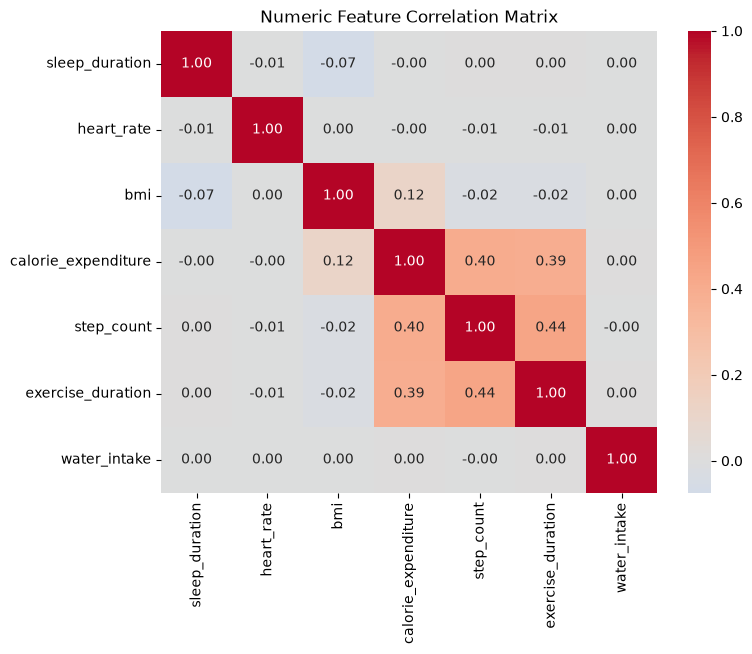


Duplicate rows (excluding id):
0

Describe (numeric):
       sleep_duration  heart_rate        bmi  calorie_expenditure  step_count  \
count       614089.00   682255.00  676190.00            637235.00   676172.00   
mean             6.99       75.10      22.98              2226.08     8615.95   
std              1.22        8.18       2.48               347.53     3929.40   
min              3.00       50.00      16.00              1200.00     1002.00   
25%              6.16       69.40      21.32              2053.00     5389.00   
50%              6.99       75.10      22.99              2241.00     8856.00   
75%              7.81       80.70      24.66              2456.00    12114.00   
max             10.00      107.70      34.82              3580.00    14999.00   

       exercise_duration  water_intake  
count          683187.00     646611.00  
mean               38.75          2.19  
std                14.74          0.52  
min                 0.00          0.50  
25%       

In [7]:
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 
                 'step_count', 'exercise_duration', 'water_intake']

print("Correlation matrix:")
corr_matrix = training_dataset[numeric_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.show()

print("\nDuplicate rows (excluding id):")
dup_count = training_dataset.drop(columns=['id']).duplicated().sum()
print(dup_count)

print("\nDescribe (numeric):")
print(training_dataset[numeric_cols].describe().round(2))

In [8]:
print("Duplicate rows (excluding id):")
dup_count = training_dataset.drop(columns=['id']).duplicated().sum()
print(dup_count)

print("\nDescribe (numeric):")
print(training_dataset[numeric_cols].describe().round(2))

Duplicate rows (excluding id):
0

Describe (numeric):
       sleep_duration  heart_rate        bmi  calorie_expenditure  step_count  \
count       614089.00   682255.00  676190.00            637235.00   676172.00   
mean             6.99       75.10      22.98              2226.08     8615.95   
std              1.22        8.18       2.48               347.53     3929.40   
min              3.00       50.00      16.00              1200.00     1002.00   
25%              6.16       69.40      21.32              2053.00     5389.00   
50%              6.99       75.10      22.99              2241.00     8856.00   
75%              7.81       80.70      24.66              2456.00    12114.00   
max             10.00      107.70      34.82              3580.00    14999.00   

       exercise_duration  water_intake  
count          683187.00     646611.00  
mean               38.75          2.19  
std                14.74          0.52  
min                 0.00          0.50  
25%        

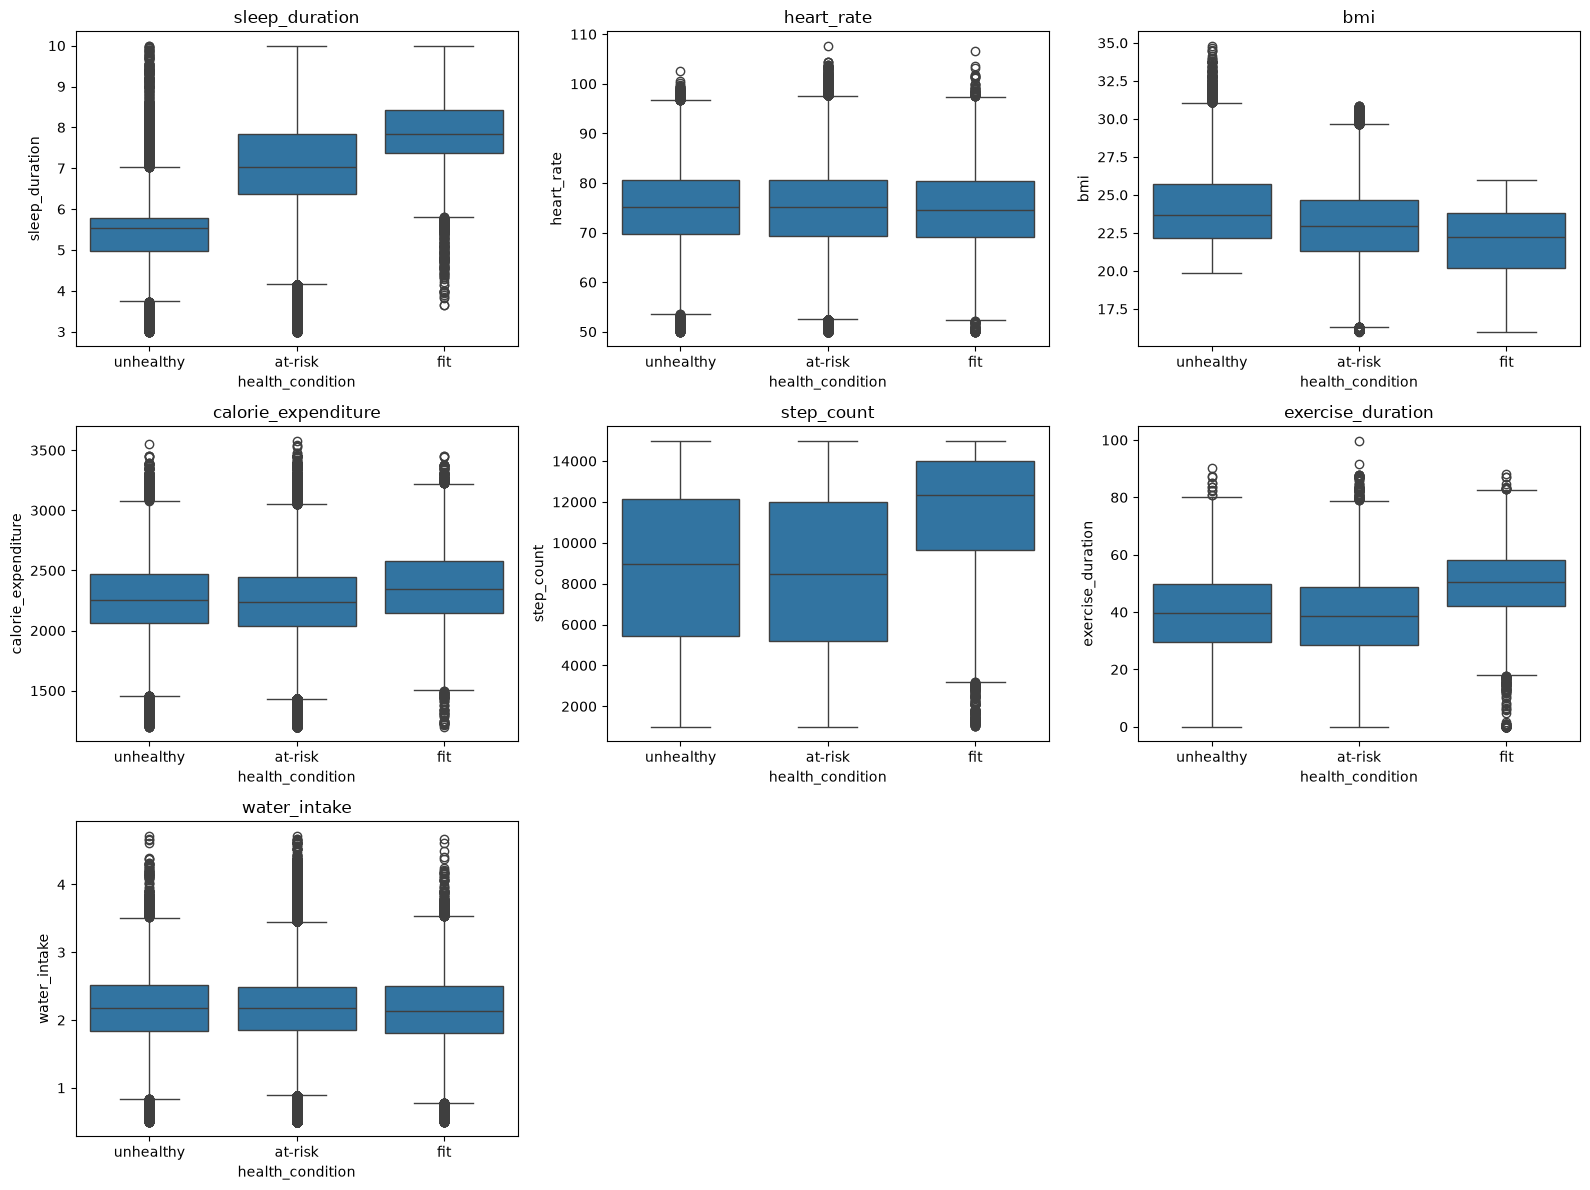

Outlier counts (IQR method, 1.5x):
sleep_duration           :    2020 outliers (0.33%) | bounds: [3.69, 10.28]
heart_rate               :    2825 outliers (0.41%) | bounds: [52.45, 97.65]
bmi                      :    5352 outliers (0.79%) | bounds: [16.31, 29.67]
calorie_expenditure      :   12831 outliers (2.01%) | bounds: [1448.50, 3060.50]
step_count               :       0 outliers (0.00%) | bounds: [-4698.50, 22201.50]
exercise_duration        :     104 outliers (0.02%) | bounds: [-1.10, 79.70]
water_intake             :   11388 outliers (1.76%) | bounds: [0.85, 3.49]


In [ ]:
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 
                 'step_count', 'exercise_duration', 'water_intake']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=training_dataset, x='health_condition', y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("Outlier counts (IQR method, 1.5x):")
for col in numeric_cols:
    Q1 = training_dataset[col].quantile(0.25)
    Q3 = training_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((training_dataset[col] < lower) | (training_dataset[col] > upper)).sum()
    outlier_pct = (outliers / training_dataset[col].notna().sum()) * 100
    print(f"{col:25s}: {outliers:7d} outliers ({outlier_pct:.2f}%) | bounds: [{lower:.2f}, {upper:.2f}]")